<a href="https://colab.research.google.com/github/nicolagherardi/AI_course_test/blob/main/Assignment_2_AH2170_Gherardi_lagfunziona.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy import stats
import matplotlib.pyplot as plt

# Import the dataset
df = pd.read_csv("AH2170_HT17_CSII_Travel_Times.csv")
df.head()

,Route,Year,Month,Day,Time,Segment Length,Travel Time
0,E3:1,2005,4,4,22635,1177,143
1,D8:1,2005,4,4,22635,604,53
2,D7:2,2005,4,4,22635,625,53
3,D6:2,2005,4,4,22635,1329,196
4,B4:2,2005,4,4,22635,997,71


# Part A

In [ ]:
df_A = df.copy()
df_A.nunique()

Route               7
Year                1
Month               1
Day                14
Time               24
Segment Length      7
Travel Time       411
dtype: int64

I want to remove year and month since they are not explanatory (1 unique value)

In [ ]:
df_A = df_A.drop(columns=['Year', 'Month'])
df_A = df_A[((df_A['Day'] >= 4) & (df_A['Day'] <= 8)) | ((df_A['Day'] >= 11) & (df_A['Day'] <= 15))]
df_A

,Route,Day,Time,Segment Length,Travel Time
0,E3:1,4,22635,1177,143
1,D8:1,4,22635,604,53
2,D7:2,4,22635,625,53
3,D6:2,4,22635,1329,196
4,B4:2,4,22635,997,71
...,...,...,...,...,...
935,E3:1,15,34335,1177,253
936,D8:1,15,34335,604,225
937,D7:2,15,34335,625,90
938,D6:2,15,34335,1329,215


In [ ]:
import pandas as pd

# 1. Create 'Unique_Time_Period' column in df_A and pivot
df_A['Unique_Time_Period'] = df_A['Day'].astype(str) + '_' + df_A['Time'].astype(str)

# Pivot the DataFrame to have routes as columns and travel times as values
df_pivot = df_A.pivot_table(index='Unique_Time_Period', columns='Route', values='Travel Time')
df_pivot = df_pivot.reset_index()
df_pivot.columns.name = None # Remove the 'Route' name from columns axis for cleaner column names

# 2. Prepare base DataFrame, keeping NaNs from pivot_table
df_base_cleaned = df_pivot.copy() # Do not drop NaNs here as requested

# 3. Reconstruct Day and Time_seconds columns from Unique_Time_Period
df_base_cleaned[['Day_str', 'Time_str']] = df_base_cleaned['Unique_Time_Period'].str.split('_', expand=True)
df_base_cleaned['Day'] = df_base_cleaned['Day_str'].astype(int)
df_base_cleaned['Time_seconds'] = df_base_cleaned['Time_str'].astype(int)

# Assuming Year=2005 and Month=4 (as per original context)
fixed_year = 2005
fixed_month = 4

# Create complete datetime objects
df_base_cleaned['datetime'] = pd.to_datetime(f'{fixed_year}-{fixed_month}-01') + \
                               (df_base_cleaned['Day'] - 1).astype('timedelta64[D]') + \
                               pd.to_timedelta(df_base_cleaned['Time_seconds'], unit='s')

# Sort by datetime to ensure correct temporal sequence
df_base_cleaned = df_base_cleaned.sort_values(by='datetime').reset_index(drop=True)

print("Initial DataFrame with datetime column and sorted (first 5 rows):")
display(df_base_cleaned.head())

# 4. Generate time-based lagged variables

dependent_variable = 'D7:2'
# List of variables to lag (excluding 'Unique_Time_Period', 'datetime', and the dependent variable)
candidates_for_lagging = [col for col in df_base_cleaned.columns if col not in ['Unique_Time_Period', 'datetime', 'Day_str', 'Time_str', 'Day', 'Time_seconds', dependent_variable]]

# Initialize the final DataFrame for the model
df_model_time_lagged = df_base_cleaned.copy()

all_new_lagged_cols = []

for lag_minutes in [15, 30]:
    lag_suffix = f'_lag{lag_minutes // 15}' # _lag1 for 15 min, _lag2 for 30 min

    # Create a DataFrame for the lagged variables
    df_lag_temp = df_base_cleaned[['datetime'] + candidates_for_lagging].copy()
    # Calculate the target datetime for the lagged variable in the main DataFrame
    df_lag_temp['datetime_target'] = df_lag_temp['datetime'] + pd.Timedelta(minutes=lag_minutes)

    # Rename columns for merging
    df_lag_temp = df_lag_temp.rename(columns={col: f'{col}{lag_suffix}' for col in candidates_for_lagging})

    # Perform the merge to add lagged variables
    # Use 'left' merge to keep all rows from the original DataFrame, introducing NaNs where no match is found
    df_model_time_lagged = pd.merge(df_model_time_lagged,
                                    df_lag_temp.drop(columns=['datetime']), # Remove datetime column from df_lag_temp to avoid conflicts
                                    left_on='datetime', right_on='datetime_target',
                                    how='left')

    # Remove the temporary 'datetime_target' column after merging
    df_model_time_lagged = df_model_time_lagged.drop(columns=['datetime_target'])

    all_new_lagged_cols.extend([f'{col}{lag_suffix}' for col in candidates_for_lagging])

# --- Final DataFrame Preparation ---
# Remove temporary columns
columns_to_drop = ['Day_str', 'Time_str', 'Day', 'Time_seconds', 'datetime']
df_final_with_lags = df_model_time_lagged.drop(columns=columns_to_drop)

# The final dropna removes rows where lagged variables or the dependent variable are NaN
# (e.g., the first slots of each day for which no lag exists, or original NaNs from pivot_table)
full_independent_candidates_list = candidates_for_lagging + all_new_lagged_cols
df_final_with_lags = df_final_with_lags.dropna(subset=[dependent_variable] + full_independent_candidates_list)

print(f"\nShape of the final DataFrame after adding time-based lagged variables and removing NaNs: {df_final_with_lags.shape}")
print("\nFinal DataFrame with lagged variables (first 10 rows):")
display(df_final_with_lags.head(10))

Initial DataFrame with datetime column and sorted (first 5 rows):


,Unique_Time_Period,B4:2,B5:2,D6:2,D7:2,D8:1,D8:2,E3:1,Day_str,Time_str,Day,Time_seconds,datetime
0,4_22635,71.0,NaN,196.0,53.0,53.0,NaN,143.0,4,22635,4,22635,2005-04-04 06:17:15
1,4_23535,76.0,191.0,130.0,50.0,51.0,87.0,118.0,4,23535,4,23535,2005-04-04 06:32:15
2,4_24435,65.0,230.0,144.0,66.0,39.0,801.0,139.0,4,24435,4,24435,2005-04-04 06:47:15
3,4_25335,136.0,265.0,144.0,64.0,179.0,438.0,107.0,4,25335,4,25335,2005-04-04 07:02:15
4,4_26235,128.0,209.0,202.0,67.0,185.0,144.0,152.0,4,26235,4,26235,2005-04-04 07:17:15



Shape of the final DataFrame after adding time-based lagged variables and removing NaNs: (69, 20)

Final DataFrame with lagged variables (first 10 rows):


,Unique_Time_Period,B4:2,B5:2,D6:2,D7:2,D8:1,D8:2,E3:1,B4:2_lag1,B5:2_lag1,D6:2_lag1,D8:1_lag1,D8:2_lag1,E3:1_lag1,B4:2_lag2,B5:2_lag2,D6:2_lag2,D8:1_lag2,D8:2_lag2,E3:1_lag2
3,4_25335,136.0,265.0,144.0,64.0,179.0,438.0,107.0,65.0,230.0,144.0,39.0,801.0,139.0,76.0,191.0,130.0,51.0,87.0,118.0
4,4_26235,128.0,209.0,202.0,67.0,185.0,144.0,152.0,136.0,265.0,144.0,179.0,438.0,107.0,65.0,230.0,144.0,39.0,801.0,139.0
5,4_27135,190.0,256.0,274.0,78.0,182.0,130.0,167.0,128.0,209.0,202.0,185.0,144.0,152.0,136.0,265.0,144.0,179.0,438.0,107.0
6,4_28035,119.0,336.0,239.0,98.0,109.0,208.0,207.0,190.0,256.0,274.0,182.0,130.0,167.0,128.0,209.0,202.0,185.0,144.0,152.0
7,4_28935,1248.0,325.0,307.0,140.0,65.0,154.0,218.0,119.0,336.0,239.0,109.0,208.0,207.0,190.0,256.0,274.0,182.0,130.0,167.0
8,4_29835,65.0,380.0,233.0,152.0,39.0,151.0,297.0,1248.0,325.0,307.0,65.0,154.0,218.0,119.0,336.0,239.0,109.0,208.0,207.0
9,4_30735,65.0,326.0,280.0,228.0,23.0,338.0,451.0,65.0,380.0,233.0,39.0,151.0,297.0,1248.0,325.0,307.0,65.0,154.0,218.0
10,4_31635,65.0,302.0,247.0,211.0,32.0,143.0,535.0,65.0,326.0,280.0,23.0,338.0,451.0,65.0,380.0,233.0,39.0,151.0,297.0
11,4_32535,65.0,307.0,274.0,199.0,24.0,380.0,493.0,65.0,302.0,247.0,32.0,143.0,535.0,65.0,326.0,280.0,23.0,338.0,451.0
12,4_33435,65.0,295.0,240.0,242.0,27.0,79.0,448.0,65.0,307.0,274.0,24.0,380.0,493.0,65.0,302.0,247.0,32.0,143.0,535.0


#1st option
We train the first model using only the travel times on OTHER links at the same time slot

Shape of DataFrame for non-lagged model: (120, 13)

Generating scatter plots for 'D7:2' against other segments...


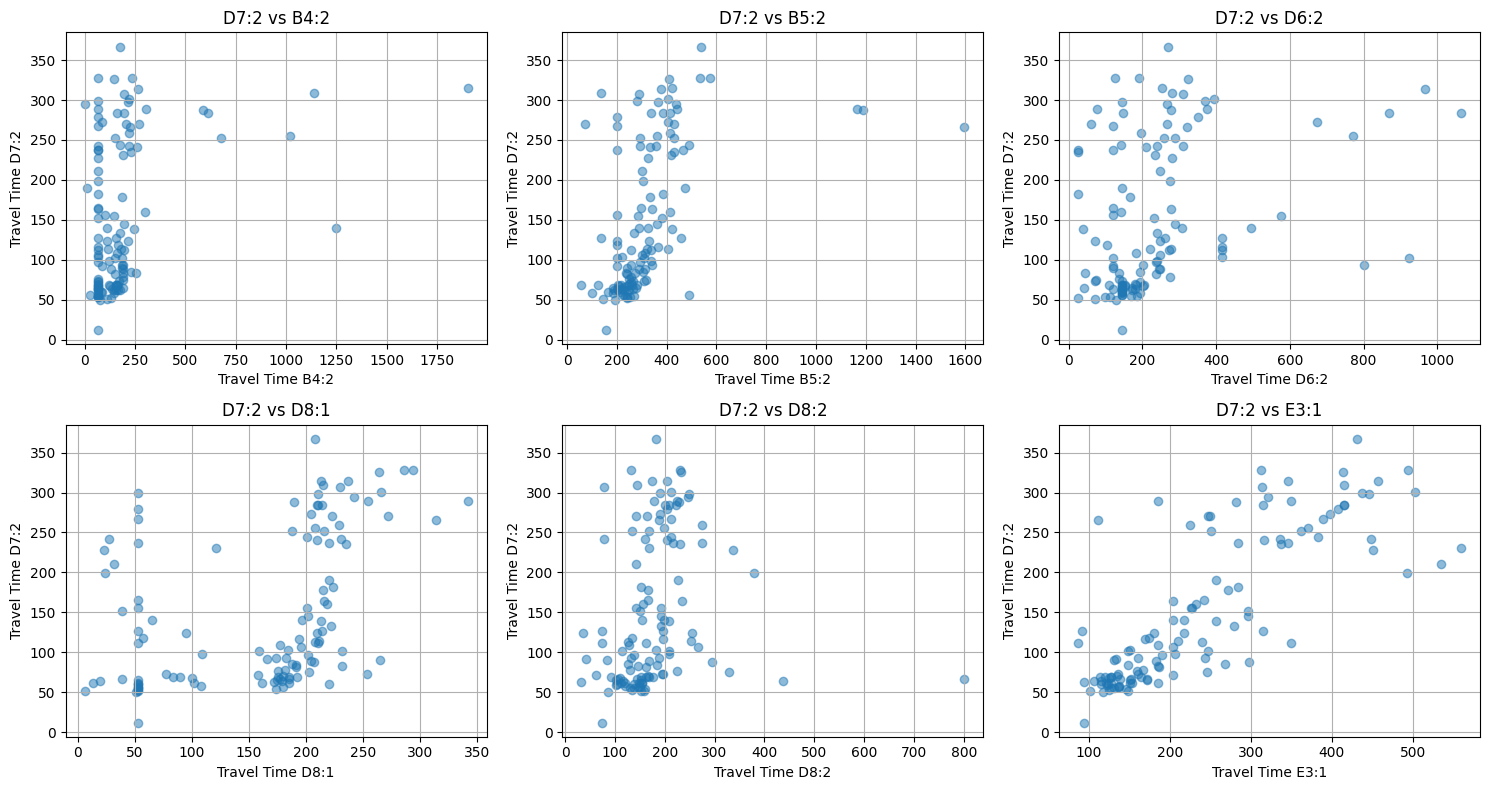

In [ ]:
# Identify the dependent variable (Y) and potential independent variables (X)
dependent_variable = 'D7:2'

# Filter out lagged variables based on their suffix as requested by 'non usare variabili lag'
independent_variables_candidates = [col for col in df_base_cleaned.columns
                                    if col not in ['Unique_Time_Period', dependent_variable, 'Day_str', 'Time_str', 'Day', 'Time_seconds', 'datetime']
                                    and not col.endswith('_lag1')
                                    and not col.endswith('_lag2')]

# Create a specific DataFrame for the non-lagged model
# This DataFrame will only drop NaNs from the dependent variable and the non-lagged candidates.
# It starts from df_base_cleaned which has original NaNs but not NaNs from lag generation.
df_for_non_lagged_model = df_base_cleaned.dropna(subset=[dependent_variable] + independent_variables_candidates).copy()

print(f"Shape of DataFrame for non-lagged model: {df_for_non_lagged_model.shape}")

if not independent_variables_candidates:
    print("No other segments found to use as independent variables.")
else:
    # --- Plotting to identify promising variables ---
    print(f"\nGenerating scatter plots for '{dependent_variable}' against other segments...")

    num_plots = len(independent_variables_candidates)
    # Determine number of rows and columns for subplots, max 3 columns per row
    cols_per_row = 3
    rows = (num_plots + cols_per_row - 1) // cols_per_row

    plt.figure(figsize=(5 * cols_per_row, 4 * rows)) # Adjust figure size dynamically
    for i, col in enumerate(independent_variables_candidates):
        plt.subplot(rows, cols_per_row, i + 1)
        # Use df_for_non_lagged_model for plotting
        plt.scatter(df_for_non_lagged_model[col], df_for_non_lagged_model[dependent_variable], alpha=0.5)
        plt.title(f'{dependent_variable} vs {col}')
        plt.xlabel(f'Travel Time {col}')
        plt.ylabel(f'Travel Time {dependent_variable}')
        plt.grid(True)

    plt.tight_layout()
    plt.show()

The most probable candidate is E3:1, but also B5:2, D6:2, D8:1 and D8:2 can be possible regressors.

In [ ]:
import statsmodels.api as sm

def forward_stepwise_selection(data, dependent_var, candidate_vars, p_threshold=0.05):

    selected_vars = []
    remaining_vars = list(candidate_vars)

    while remaining_vars:
        best_p_value = p_threshold + 0.01 # Initialize with a value higher than threshold
        best_new_var = None

        for var in remaining_vars:
            current_vars = selected_vars + [var]
            # Fix: Changed current_var_names to current_vars
            X = sm.add_constant(data[current_vars])
            Y = data[dependent_var]

            try:
                model = sm.OLS(Y, X).fit()
                # Check if the variable is in the pvalues. This can be tricky if a variable
                # is perfectly collinear with existing variables. In such cases, statsmodels
                # might drop it or assign a NaN p-value.
                if var in model.pvalues:
                    new_var_p_value = model.pvalues[var]
                else:
                    # If the variable is not in pvalues (e.g., dropped due to collinearity), consider it non-significant
                    new_var_p_value = 1.0 # Or use a value > p_threshold

                if new_var_p_value < best_p_value:
                    best_p_value = new_var_p_value
                    best_new_var = var
            except Exception as e:
                # Handle cases where model fitting might fail (e.g., due to perfect multicollinearity for small samples)
                print(f"Warning: Could not fit model with {current_vars}. Error: {e}")
                continue

        if best_new_var and best_p_value < p_threshold:
            selected_vars.append(best_new_var)
            remaining_vars.remove(best_new_var)
            print(f"Added '{best_new_var}' to the model (p-value: {best_p_value:.4f})")
        else:
            break # No more variables to add that meet the significance criterion

    return selected_vars


# Define Y using df_for_non_lagged_model
Y = df_for_non_lagged_model[dependent_variable]

# Define X_candidates to include all non-dependent variables from df_for_non_lagged_model
# These candidates are already filtered to exclude lagged variables in ZjlCQsK_DPFj
X_candidates = independent_variables_candidates

# Select independent variables using forward stepwise selection
print(f"\nPerforming Forward Stepwise Selection for '{dependent_variable}' (excluding lagged variables)...")
selected_X_cols = forward_stepwise_selection(df_for_non_lagged_model, dependent_variable, X_candidates, p_threshold=0.05)

if not selected_X_cols:
    print("No suitable independent variables found by stepwise selection for the given p-threshold.")
else:
    X = df_for_non_lagged_model[selected_X_cols]

    # Add a constant to the independent variables for statsmodels
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(Y, X)
    results = model.fit()

    # Print the regression results
    print("\nRegression Results (Forward Stepwise Selection):")
    print(results.summary())


Performing Forward Stepwise Selection for 'D7:2' (excluding lagged variables)...
Added 'E3:1' to the model (p-value: 0.0000)
Added 'B5:2' to the model (p-value: 0.0000)
Added 'D8:1' to the model (p-value: 0.0060)
Added 'B4:2' to the model (p-value: 0.0222)

Regression Results (Forward Stepwise Selection):
                            OLS Regression Results                            
Dep. Variable:                   D7:2   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     94.11
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           2.42e-35
Time:                        20:06:57   Log-Likelihood:                -626.76
No. Observations:                 120   AIC:                             1264.
Df Residuals:                     115   BIC:                             1277.
Df Model:                           4                       

Assumptions checking on residuals:

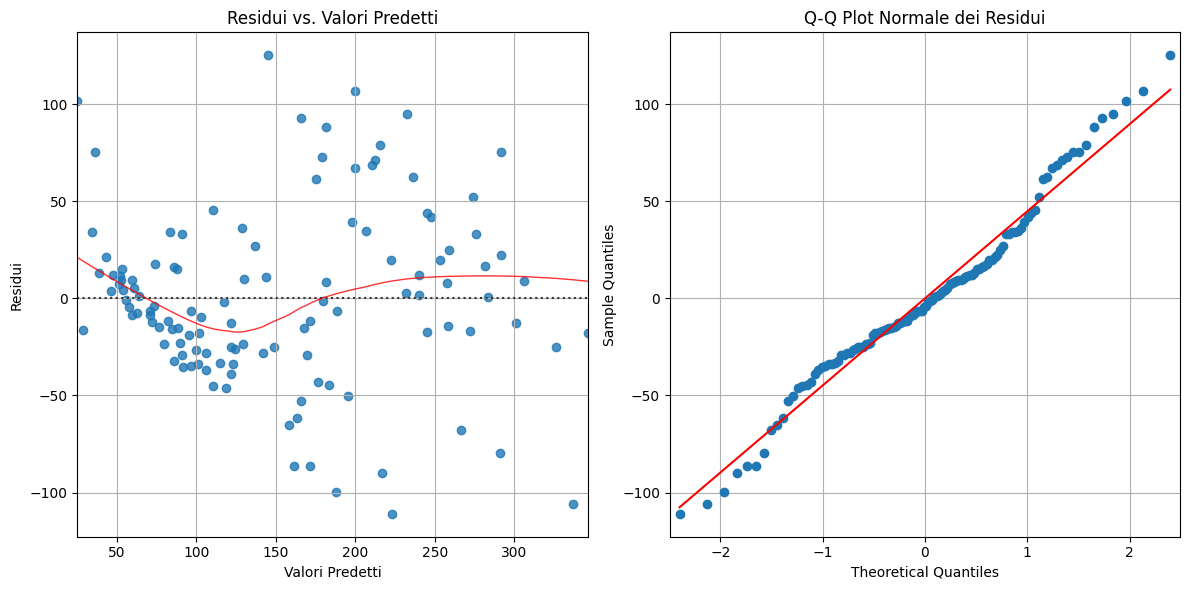


Grafici dei Residui vs. le Variabili Indipendenti Selezionate:


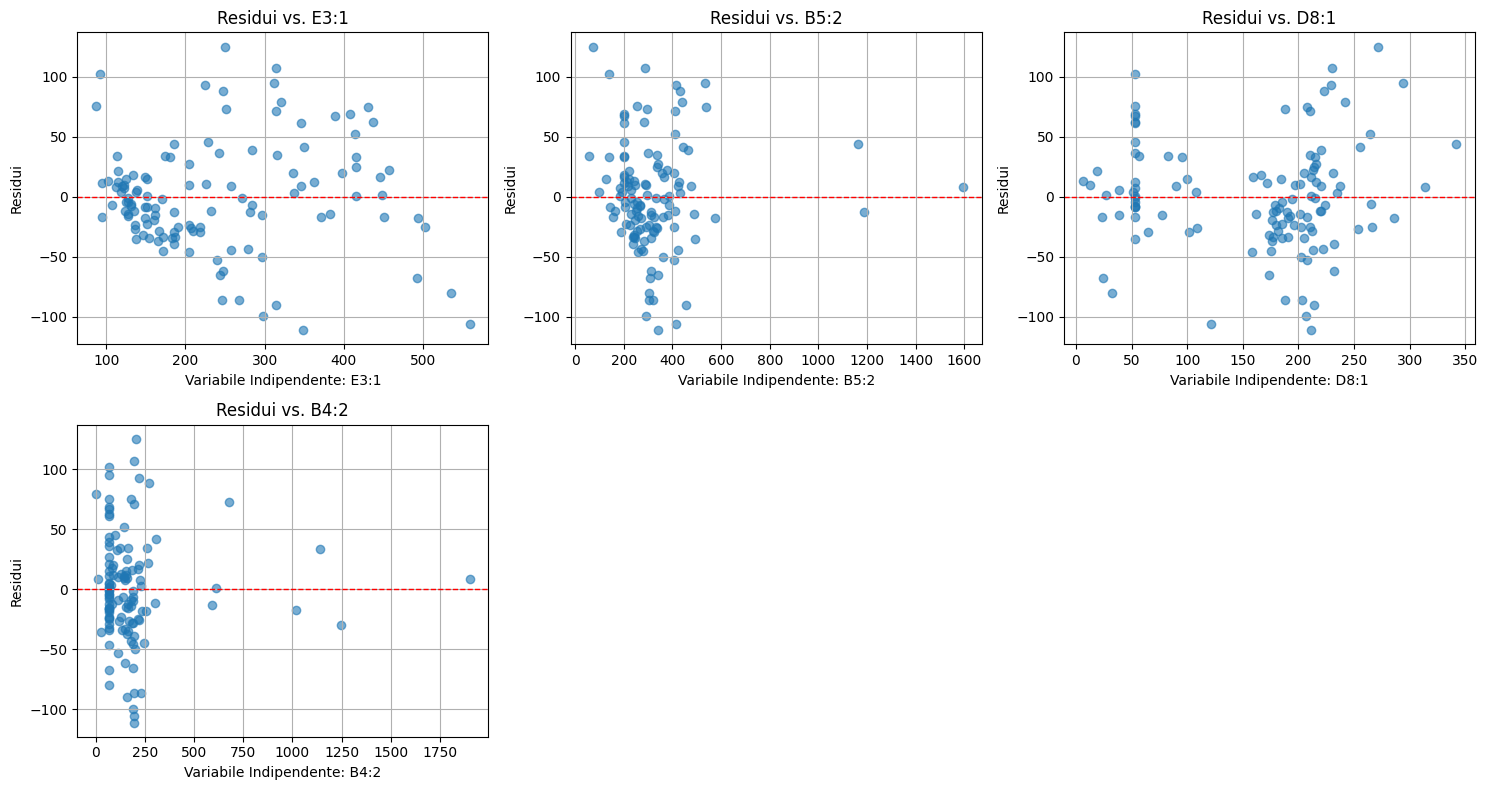

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# Assuming 'results' is the OLSResults object from the non-lagged model (from cell OFLdYVxMEmSq)
# and 'X' is the DataFrame of independent variables used in that model.

# 1. Residuals vs. Fitted Values Plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.residplot(x=results.fittedvalues, y=results.resid, lowess=True, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.xlabel('Valori Predetti')
plt.ylabel('Residui')
plt.title('Residui vs. Valori Predetti')
plt.grid(True)

# 2. Normal Q-Q Plot of Residuals
plt.subplot(1, 2, 2)
sm.qqplot(results.resid, line='s', ax=plt.gca())
plt.title('Q-Q Plot Normale dei Residui')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Residuals vs. Independent Variables Plots
print("\nGrafici dei Residui vs. le Variabili Indipendenti Selezionate:")
# 'X' contains the independent variables plus the constant. We need to exclude the 'const'
X_vars = X.drop(columns='const', errors='ignore')

num_plots = len(X_vars.columns)
cols_per_row = 3
rows = (num_plots + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(5 * cols_per_row, 4 * rows))
for i, col in enumerate(X_vars.columns):
    plt.subplot(rows, cols_per_row, i + 1)
    plt.scatter(X_vars[col], results.resid, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--', lw=1)
    plt.xlabel(f'Variabile Indipendente: {col}')
    plt.ylabel('Residui')
    plt.title(f'Residui vs. {col}')
    plt.grid(True)
plt.tight_layout()
plt.show()

Runs test statistic = -4.739
Runs test p-value = 0.000



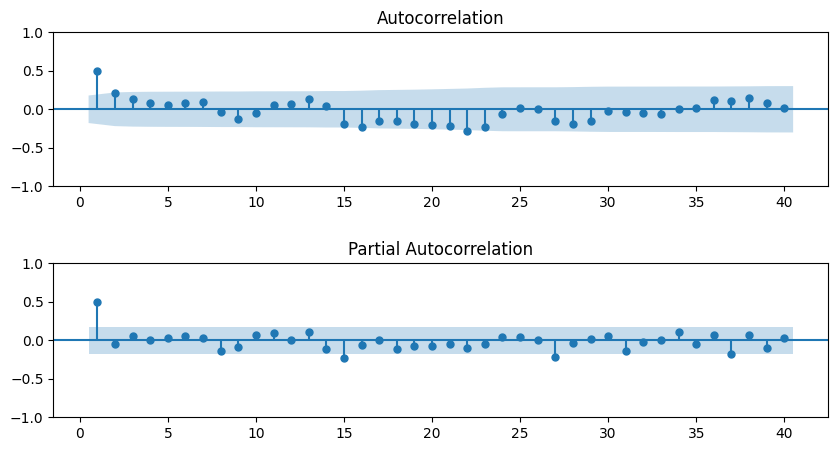

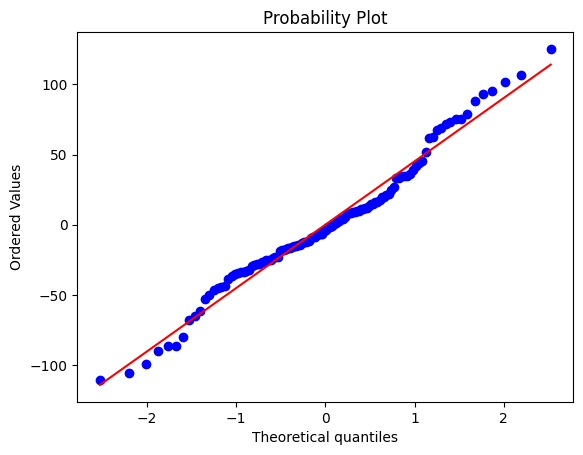

Anderson-darling test statistic = 1.068
Anderson-darling test p-value = 0.008


In [ ]:
import qdatoolkit as qda

_ = qda.Assumptions(results.resid).independence()
_ = qda.Assumptions(results.resid).normality()

# 2nd option
For the second option I considered the "time travel" at lag 1 and 2 for each route

In [ ]:
import statsmodels.api as sm

# The dependent variable remains the same
# Y needs to be defined from df_final_with_lags for alignment
Y = df_final_with_lags[dependent_variable]

# Define X_candidates to include ALL non-dependent variables from df_final_with_lags,
# including both original and lagged variables.
# The list `full_independent_candidates_list` from uEa5c_ldSXT3 already contains these.
X_candidates_with_lags = full_independent_candidates_list

print(f"\nPerforming Forward Stepwise Selection for '{dependent_variable}' (including lagged variables)...\n")
selected_X_cols_with_lags = forward_stepwise_selection(df_final_with_lags, dependent_variable, X_candidates_with_lags, p_threshold=0.05)

if not selected_X_cols_with_lags:
    print("No suitable independent variables (including lagged) found by stepwise selection for the given p-threshold.")
else:
    X_with_lags = df_final_with_lags[selected_X_cols_with_lags]

    # Add a constant to the independent variables for statsmodels
    X_with_lags = sm.add_constant(X_with_lags)

    # Fit the OLS model
    model_with_lags = sm.OLS(Y, X_with_lags)
    results_with_lags = model_with_lags.fit()

    # Print the regression results
    print("\nRegression Results (Forward Stepwise Selection with Lagged Variables):")
    print(results_with_lags.summary())


Performing Forward Stepwise Selection for 'D7:2' (including lagged variables)...

Added 'E3:1' to the model (p-value: 0.0000)
Added 'B5:2_lag1' to the model (p-value: 0.0000)
Added 'D8:1' to the model (p-value: 0.0171)
Added 'E3:1_lag1' to the model (p-value: 0.0271)

Regression Results (Forward Stepwise Selection with Lagged Variables):
                            OLS Regression Results                            
Dep. Variable:                   D7:2   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     43.43
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           1.42e-17
Time:                        20:07:00   Log-Likelihood:                -365.65
No. Observations:                  69   AIC:                             741.3
Df Residuals:                      64   BIC:                             752.5
Df Model:                  

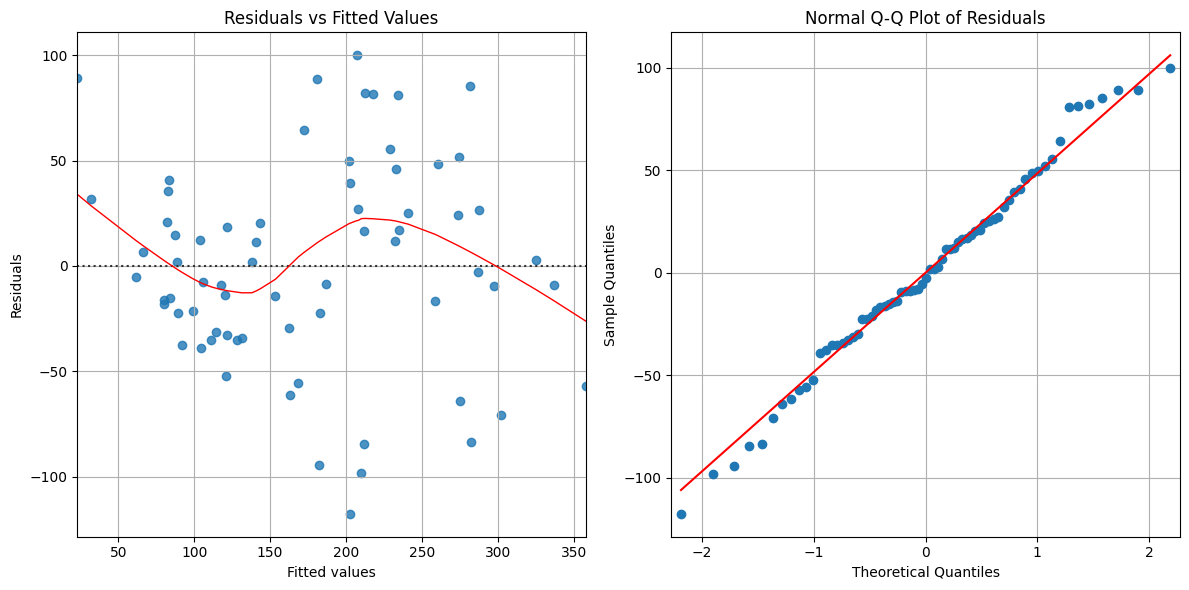

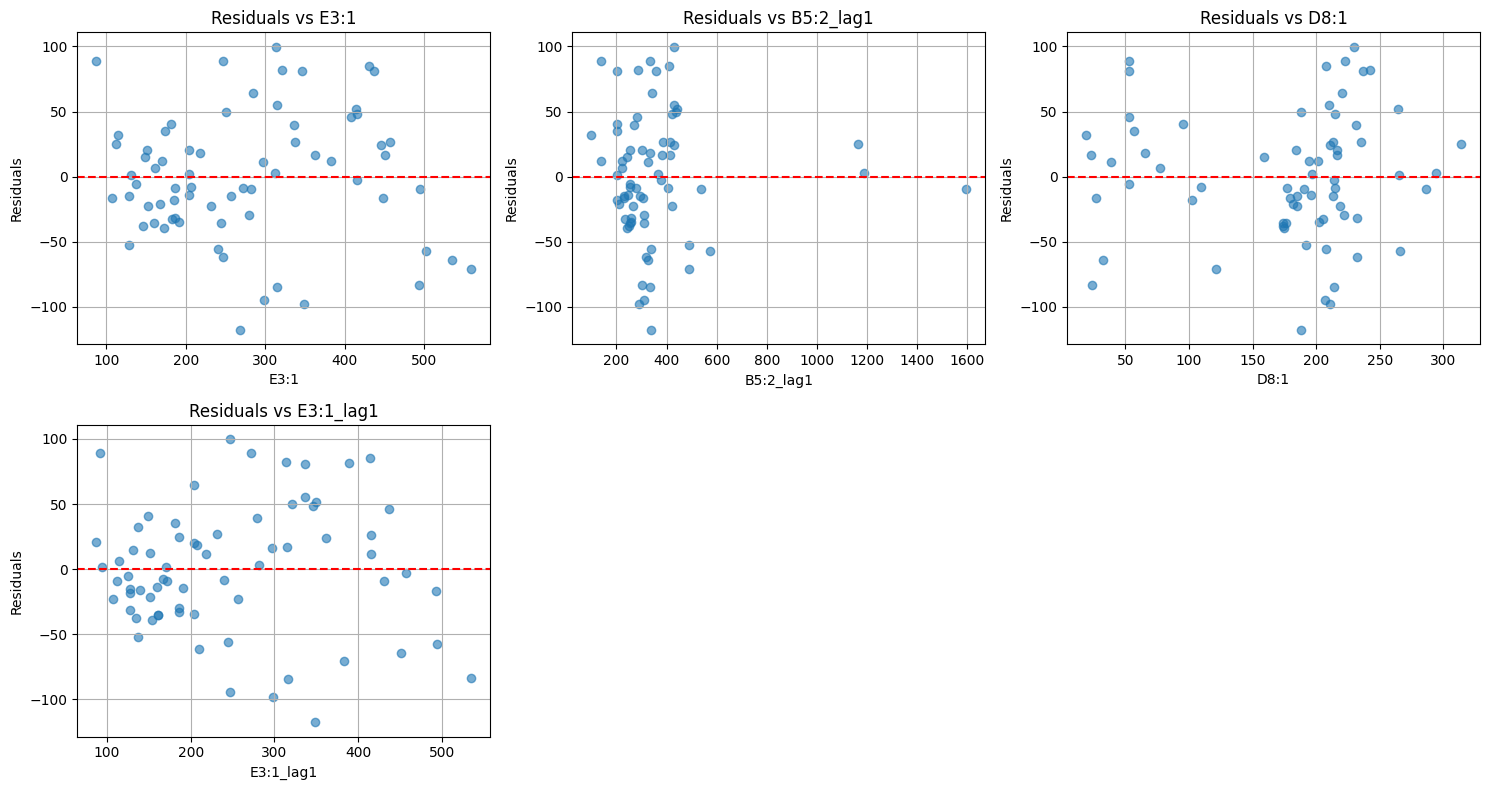

In [ ]:
# Residual diagnostics for the model including lagged variables

residuals = results_with_lags.resid
X_vars_with_lags = X_with_lags.drop(columns='const', errors='ignore')

# 1. Residuals vs fitted values and normal Q-Q plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.residplot(
    x=results_with_lags.fittedvalues,
    y=residuals,
    lowess=True,
    line_kws={'color': 'red', 'lw': 1}
)
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.grid(True)

plt.subplot(1, 2, 2)
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('Normal Q-Q Plot of Residuals')
plt.grid(True)

plt.tight_layout()
plt.show()

# 2. Residuals against each selected explanatory variable
cols_per_row = 3
num_plots = len(X_vars_with_lags.columns)
rows = (num_plots + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(5 * cols_per_row, 4 * rows))

for i, col in enumerate(X_vars_with_lags.columns):
    plt.subplot(rows, cols_per_row, i + 1)
    plt.scatter(X_vars_with_lags[col], residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel(col)
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs {col}')
    plt.grid(True)

plt.tight_layout()
plt.show()

Runs test statistic = -4.244
Runs test p-value = 0.000



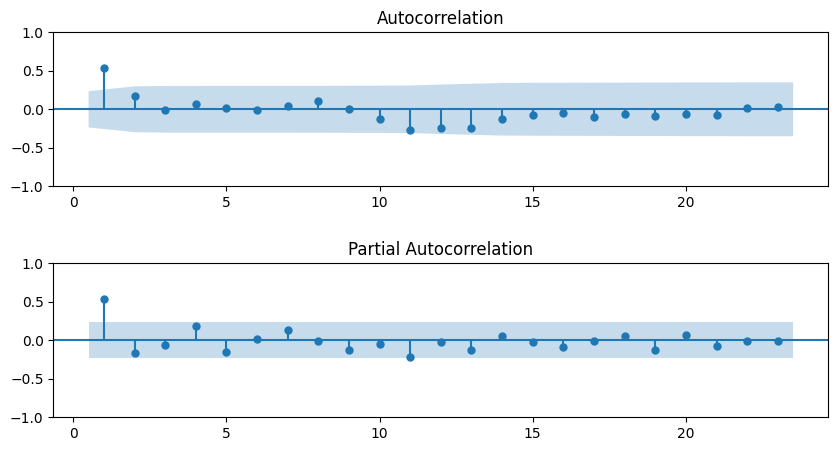

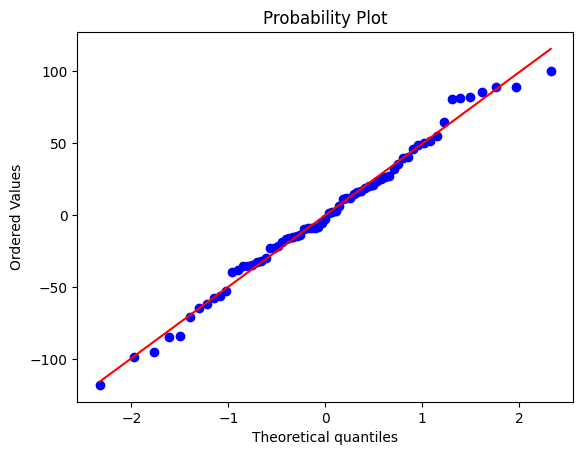

Anderson-darling test statistic = 0.214
Anderson-darling test p-value = 0.851


In [ ]:
import qdatoolkit as qda
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

# Part B

,Route,Day,Time,Segment Length,Travel Time
940,E3:1,18,22635,1177,106
941,D8:1,18,22635,604,19
942,D7:2,18,22635,625,58
943,D6:2,18,22635,1329,177
944,B4:2,18,22635,997,73


Original evaluation dataset shape: (376, 5)
Evaluation dataset after datetime construction and sorting:


,Unique_Time_Period,B4:2,B5:2,D6:2,D7:2,D8:1,D8:2,E3:1,Day_str,Time_str,Day,Time_seconds,datetime
0,18_22635,73.0,NaN,177.0,58.0,19.0,NaN,106.0,18,22635,18,22635,2005-04-18 06:17:15
1,18_23535,146.0,201.0,187.0,21.0,36.0,121.0,147.0,18,23535,18,23535,2005-04-18 06:32:15
2,18_24435,103.0,201.0,144.0,24.0,53.0,127.0,127.0,18,24435,18,24435,2005-04-18 06:47:15
3,18_25335,172.0,207.0,144.0,52.0,2.0,69.0,154.0,18,25335,18,25335,2005-04-18 07:02:15
4,18_26235,103.0,172.0,183.0,35.0,19.0,101.0,162.0,18,26235,18,26235,2005-04-18 07:17:15


Final evaluation dataset shape after adding lagged variables and removing NaNs: (34, 20)


,Unique_Time_Period,B4:2,B5:2,D6:2,D7:2,D8:1,D8:2,E3:1,B4:2_lag1,B5:2_lag1,D6:2_lag1,D8:1_lag1,D8:2_lag1,E3:1_lag1,B4:2_lag2,B5:2_lag2,D6:2_lag2,D8:1_lag2,D8:2_lag2,E3:1_lag2
3,18_25335,172.0,207.0,144.0,52.0,2.0,69.0,154.0,103.0,201.0,144.0,53.0,127.0,127.0,146.0,201.0,187.0,36.0,121.0,147.0
4,18_26235,103.0,172.0,183.0,35.0,19.0,101.0,162.0,172.0,207.0,144.0,2.0,69.0,154.0,103.0,201.0,144.0,53.0,127.0,127.0
5,18_27135,167.0,109.0,225.0,169.0,182.0,94.0,192.0,103.0,172.0,183.0,19.0,101.0,162.0,172.0,207.0,144.0,2.0,69.0,154.0
6,18_28035,190.0,97.0,186.0,215.0,264.0,119.0,209.0,167.0,109.0,225.0,182.0,94.0,192.0,103.0,172.0,183.0,19.0,101.0,162.0
7,18_28935,114.0,3.0,224.0,35.0,268.0,152.0,252.0,190.0,97.0,186.0,264.0,119.0,209.0,167.0,109.0,225.0,182.0,94.0,192.0
8,18_29835,68.0,169.0,300.0,317.0,235.0,135.0,450.0,114.0,3.0,224.0,268.0,152.0,252.0,190.0,97.0,186.0,264.0,119.0,209.0
9,18_30735,65.0,169.0,281.0,35.0,232.0,157.0,414.0,68.0,169.0,300.0,235.0,135.0,450.0,114.0,3.0,224.0,268.0,152.0,252.0
10,18_31635,65.0,169.0,205.0,35.0,317.0,138.0,481.0,65.0,169.0,281.0,232.0,157.0,414.0,68.0,169.0,300.0,235.0,135.0,450.0
11,18_32535,65.0,169.0,223.0,35.0,269.0,55.0,483.0,65.0,169.0,205.0,317.0,138.0,481.0,65.0,169.0,281.0,232.0,157.0,414.0
12,18_33435,65.0,169.0,228.0,282.0,292.0,157.0,416.0,65.0,169.0,223.0,269.0,55.0,483.0,65.0,169.0,205.0,317.0,138.0,481.0


Out-of-sample performance on Part B:

Option 1 — Contemporaneous variables
R²   = 0.005
RMSE = 124.28

Option 2 — Contemporaneous + lagged variables
R²   = -0.130
RMSE = 132.46


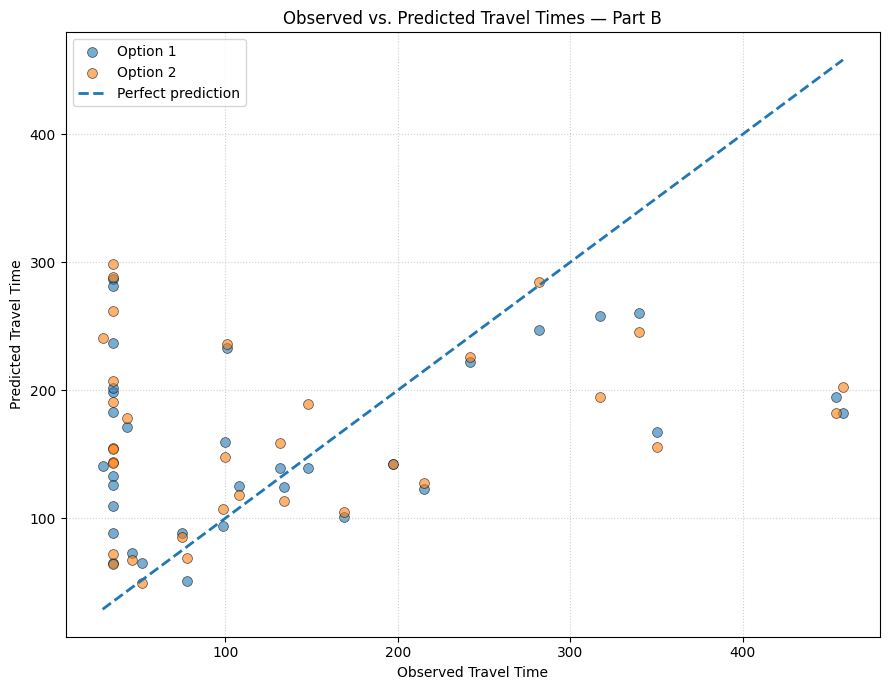

In [ ]:
# PART B — Evaluation on the independent dataset

# Select the evaluation period
df_B_eval = df.copy()
df_B_eval = df_B_eval[(df_B_eval['Day'] >= 18) & (df_B_eval['Day'] <= 21)]
df_B_eval = df_B_eval.drop(columns=['Year', 'Month'])

display(df_B_eval.head())
print(f"Original evaluation dataset shape: {df_B_eval.shape}")

# 1. Create 'Unique_Time_Period' and pivot the evaluation dataset

df_B_eval['Unique_Time_Period'] = (
    df_B_eval['Day'].astype(str) + '_' + df_B_eval['Time'].astype(str)
)

df_B_pivot = df_B_eval.pivot_table(
    index='Unique_Time_Period',
    columns='Route',
    values='Travel Time'
)

df_B_pivot = df_B_pivot.reset_index()
df_B_pivot.columns.name = None

# Keep NaNs at this stage, exactly as in Part A
df_B_base = df_B_pivot.copy()

# 2. Reconstruct Day and Time_seconds

df_B_base[['Day_str', 'Time_str']] = (
    df_B_base['Unique_Time_Period'].str.split('_', expand=True)
)

df_B_base['Day'] = df_B_base['Day_str'].astype(int)
df_B_base['Time_seconds'] = df_B_base['Time_str'].astype(int)

# 3. Create datetime exactly as in Part A

fixed_year_B = 2005
fixed_month_B = 4

df_B_base['datetime'] = (
    pd.to_datetime(f'{fixed_year_B}-{fixed_month_B}-01')
    + (df_B_base['Day'] - 1).astype('timedelta64[D]')
    + pd.to_timedelta(df_B_base['Time_seconds'], unit='s')
)

# Sort chronologically
df_B_base = (
    df_B_base
    .sort_values(by='datetime')
    .reset_index(drop=True)
)

print("Evaluation dataset after datetime construction and sorting:")
display(df_B_base.head())

# 4. Generate the same time-based lagged variables used in Part A

dependent_variable_B = 'D7:2'

# Identify the variables to lag using the same logic as Part A
candidates_for_lagging_B = [
    col for col in df_B_base.columns
    if col not in [
        'Unique_Time_Period',
        'datetime',
        'Day_str',
        'Time_str',
        'Day',
        'Time_seconds',
        dependent_variable_B
    ]
]

df_B_model_time_lagged = df_B_base.copy()

all_new_lagged_cols_B = []

for lag_minutes in [15, 30]:

    lag_suffix_B = f'_lag{lag_minutes // 15}'

    # Select datetime and the variables to be lagged
    df_B_lag_temp = df_B_base[
        ['datetime'] + candidates_for_lagging_B
    ].copy()

    # Target datetime
    df_B_lag_temp['datetime_target'] = (
        df_B_lag_temp['datetime']
        + pd.Timedelta(minutes=lag_minutes)
    )

    # Rename lagged variables
    df_B_lag_temp = df_B_lag_temp.rename(
        columns={
            col: f'{col}{lag_suffix_B}'
            for col in candidates_for_lagging_B
        }
    )

    # Merge using the same logic as Part A
    df_B_model_time_lagged = pd.merge(
        df_B_model_time_lagged,
        df_B_lag_temp.drop(columns=['datetime']),
        left_on='datetime',
        right_on='datetime_target',
        how='left'
    )

    # Remove temporary merge column
    df_B_model_time_lagged = df_B_model_time_lagged.drop(
        columns=['datetime_target']
    )

    all_new_lagged_cols_B.extend(
        [
            f'{col}{lag_suffix_B}'
            for col in candidates_for_lagging_B
        ]
    )

# 5. Final preparation of the evaluation dataset
#    Same preparation as Part A

columns_to_drop_B = [
    'Day_str',
    'Time_str',
    'Day',
    'Time_seconds',
    'datetime'
]

df_B_final_with_lags = df_B_model_time_lagged.drop(
    columns=columns_to_drop_B
)

full_independent_candidates_list_B = (
    candidates_for_lagging_B
    + all_new_lagged_cols_B
)

# Remove rows containing NaNs in the dependent variable
# or in any candidate explanatory variable
df_B_final_with_lags = df_B_final_with_lags.dropna(
    subset=[
        dependent_variable_B
    ] + full_independent_candidates_list_B
)

print(
    "Final evaluation dataset shape after "
    "adding lagged variables and removing NaNs:",
    df_B_final_with_lags.shape
)

display(df_B_final_with_lags.head(10))

# 6. Prepare the evaluation data for the two models

# Observed target
y_B_observed = df_B_final_with_lags[dependent_variable_B]

# ---------------------------------------------------------
# OPTION 1 — Model without lagged variables
# ---------------------------------------------------------

X_B_option1 = df_B_final_with_lags[
    selected_X_cols
]

X_B_option1 = sm.add_constant(
    X_B_option1,
    has_constant='add'
)

# Prediction using the model fitted in Part A
y_B_forecast_option1 = results.predict(
    X_B_option1
)


# ---------------------------------------------------------
# OPTION 2 — Model with lagged variables
# ---------------------------------------------------------

X_B_option2 = df_B_final_with_lags[
    selected_X_cols_with_lags
]

X_B_option2 = sm.add_constant(
    X_B_option2,
    has_constant='add'
)

# Prediction using the model fitted in Part A
y_B_forecast_option2 = results_with_lags.predict(
    X_B_option2
)

# 7. Calculate out-of-sample performance

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# OPTION 1
r2_B_option1 = r2_score(
    y_B_observed,
    y_B_forecast_option1
)

rmse_B_option1 = np.sqrt(
    mean_squared_error(
        y_B_observed,
        y_B_forecast_option1
    )
)

# OPTION 2
r2_B_option2 = r2_score(
    y_B_observed,
    y_B_forecast_option2
)

rmse_B_option2 = np.sqrt(
    mean_squared_error(
        y_B_observed,
        y_B_forecast_option2
    )
)

print("Out-of-sample performance on Part B:")
print("\nOption 1 — Contemporaneous variables")
print(f"R²   = {r2_B_option1:.3f}")
print(f"RMSE = {rmse_B_option1:.2f}")

print("\nOption 2 — Contemporaneous + lagged variables")
print(f"R²   = {r2_B_option2:.3f}")
print(f"RMSE = {rmse_B_option2:.2f}")

# 8. Observed vs. predicted values

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=y_B_observed,
    y=y_B_forecast_option1,
    alpha=0.6,
    edgecolor='k',
    s=50,
    label='Option 1'
)

sns.scatterplot(
    x=y_B_observed,
    y=y_B_forecast_option2,
    alpha=0.6,
    edgecolor='k',
    s=50,
    label='Option 2'
)

min_val = min(
    y_B_observed.min(),
    y_B_forecast_option1.min(),
    y_B_forecast_option2.min()
)

max_val = max(
    y_B_observed.max(),
    y_B_forecast_option1.max(),
    y_B_forecast_option2.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2,
    label='Perfect prediction'
)

plt.xlabel('Observed Travel Time')
plt.ylabel('Predicted Travel Time')
plt.title('Observed vs. Predicted Travel Times — Part B')

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
X_B = df_final_with_lags[full_independent_candidates_list]
y_observed = df_final_with_lags[dependent_variable]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# 1. Calcolo dei valori previsti (forecast) dal modello OLS
# y_forecast = nomedelmodello.predict(X_B)
y_forecast = results.predict()

# 2. Calcolo delle metriche di performance
r2 = r2_score(y_observed, y_forecast)
rmse = np.sqrt(mean_squared_error(y_observed, y_forecast))

# 3. Creazione dello Scatter Plot (Observed vs. Forecast)
plt.figure(figsize=(9, 7))

# Scatter plot dei punti reali vs previsti
sns.scatterplot(
    x=y_observed,
    y=y_forecast,
    alpha=0.6,
    color='#1f77b4',
    edgecolor='k',
    s=50,
    label='Osservazioni'
)

# Linea di perfezione 45° (y = x)
min_val = min(y_observed.min(), y_forecast.min())
max_val = max(y_observed.max(), y_forecast.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Perfetto adattamento (y = x)'
)

# Etichette e titoli
plt.xlabel('Tempi di Percorrenza Osservati (Observed Travel Times)', fontsize=12)
plt.ylabel('Tempi di Percorrenza Previsti (Forecast Travel Times)', fontsize=12)
plt.title('Confronto Tempi di Percorrenza: Osservati vs. Previsti (D7:2)', fontsize=14, fontweight='bold')

# Box informativo con le metriche R² e RMSE
metrics_text = f'$R^2 = {r2:.3f}$\n$RMSE = {rmse:.2f}$'
plt.gca().text(
    0.05, 0.92, metrics_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [69, 120]